# Assignment 1: Linear Classification and Regression

This assignment has **50 marks (6.5% of final grades)**.


**Deadline: October 9 at 11:59PM**


We will cover a variety of lectures and tutorials in this assignment including  Linear regression and classification.

Please note that similar codes between individuals will considered violation under the academic integrity policy, and the instructor holds the right to take any necessarry action.

## Note
* Use Google Colab to do this assignment.
* Don't change existing code or text.
* Add code and write text as instructed.
* Please pay attention to questions asked after writing code to analyze or conclude results (I usually put them in bullet points and bold them)

## Submission
* File > Download > (as .ipynb)
* Submit .ipynb file on the Learn.
* Please submit by the deadline

## Submission Notes
(Please write any notes or assumptions here that you think we should know during marking)

- The assignment explicitly mentioned we are using only first two class. Drop the third class initially before splitting the dataframe.

# Linear Classification and Regression



## Problem 1: Linear Classification and Regression on Iris flower dataset [50 marks]


The Iris flowers dataset is aviqlable on sklearn. The dataset consists of 50 samples from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor). Four features were measured from each sample: the length and the width of the sepals and petals, in centimeters. Based on the combination of these four features, we can develop a linear classifier and regression to distinguish the species from each other. https://en.wikipedia.org/wiki/Iris_flower_data_set

We will only work with the first 2 flower classes (Setosa and Versicolour), and with just the length and width features of the sepal for the classification part.

For the Linear Regression, we will predict only the sepal length of the flowers







In [25]:
import matplotlib
import numpy as np
import pandas as pd
from sklearn import datasets
import matplotlib.pyplot as plt
%matplotlib inline
#add other libraries if needed

Load the Dataset

In [26]:
iris = datasets.load_iris()
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

# Adding some noise to make it more challenging
Creating a pandas dataframe from the observations.



In [ ]:
I=np.random.normal(1.0, 0.2, size=(4, 150))# Adding noise - you can change that if needed
for i in range(4):
  iris.data[:,i]=np.random.normal(1.0,0.2)*iris.data[:,i]*I[i,:]

Features = pd.DataFrame(iris.data, columns=iris.feature_names)
Target = pd.DataFrame(iris.target, columns=['Target'])

IrisData = pd.concat([Target, Features], axis = 1)
# Create two Class Split
IrisData = IrisData[IrisData['Target'] != 2]
IrisData['Target'] = IrisData['Target'].replace(0, -1)

df = Features
df
IrisData

ValueError: Series.replace must specify either 'value', a dict-like 'to_replace', or dict-like 'regex'.

## Take 25% of data as the test data

In [28]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.25)
test

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
45,6.212189,3.102264,1.464083,0.289614
5,5.313690,4.646747,1.485169,0.470885
66,6.198142,3.933185,6.393060,1.488109
120,9.700862,3.612383,5.709681,2.372707
106,6.625362,2.197706,4.936697,1.771820
138,7.625303,4.165167,5.781660,1.616630
116,7.405987,3.494836,6.684937,2.148275
34,7.084046,4.150743,2.157887,0.134865
133,4.220951,3.213368,6.060041,0.982683
47,5.250552,4.613593,1.596040,0.187732


# Q1: Plot the Iris dataset  [3 pts]

Plot the length and width features as a scatter plot for each of the 2 flower classes Setosa and Versicolour


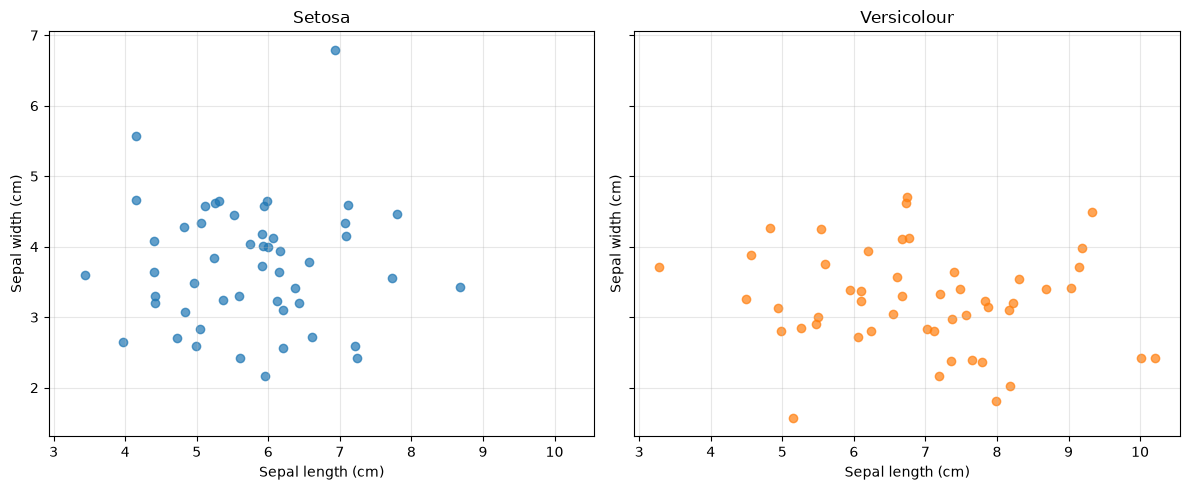

In [29]:
from enum import Enum

# Assert Dataset Size
assert df.shape == (150,4)
assert Target.shape == (150, 1)

# Assign Flower Class
class IrisClass(Enum):
    SETOSA = 0
    VERSICOLOUR = 1
    VIRGINICA = 2

# Extract each flower class dataset
setosa_df = df[Target['Target'] == IrisClass.SETOSA.value]
versicolour_df = df[Target['Target'] == IrisClass.VERSICOLOUR.value]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for ax, data, name, color in [
    (axes[0], setosa_df, 'Setosa', 'tab:blue'),
    (axes[1], versicolour_df, 'Versicolour', 'tab:orange'),
]:
    ax.scatter(data['sepal length (cm)'], data['sepal width (cm)'], color=color, alpha=0.7)
    ax.set_title(name)
    ax.set_xlabel('Sepal length (cm)')
    ax.set_ylabel('Sepal width (cm)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Q2: What can you conclude about the decision boundary choice? [2 pts]



*   ***Answer to Q2:***



The linear function for weight can be generalized to f(x)=w_1x_1 + w_2x_2. Linear classifier are only able to classify two distinct class. If f(x)>0, the object belongs to setosa class and when f(x)<0 the object belongs to versicolour class. If the f(x)=0 on te line exactly the linear classifier cannot decide it's class.

# Q3: Linear Classification using gradient descent [25 pts]

Using the gradient descent algorithm we did in class in lecture 4 solve the Iris dataset problem. Make sure you comment your code and write down any explanation necessary for partial marks


**Write down your assumptions or steps you want us to look at here:**

*   
*   



Start with training predictions to create your predictor



In [30]:
#Write your training code here and comment it

Now using the test set test the accuracy of your predictor

In [31]:
#Write your testing code here and comment it

# Q4: Using sklearn for Classification [10 pts]

Using sklearn built in logistic regression model, solve the Iris classication problem. [5 pts]

In [32]:
#Write your code here and comment it
import sklearn.linear_model



*   Compare your results against your Classifier from Q3. Conclude as why one may perform better than the other. [5 pts]

**Answer:**




# Q5: Using sklearn for Linear Regression [10 pts]

---



Using sklearn built in linear regression model, predict the sepal length of the iris flowers. [10 pts]


From your code in part 1:

*   Load the sepal length for your prediction and split the data into training testing again
*   Use the sepal width, petal width, petal length, and the species as your input
*   Train your predictor to approximates the sepal length using the built in linear regression model from sklearn
*   Evaluate your model using the mean squared error (use the built in function in sklearn)
*   Test your predictor using the test set and report both predictions (sepal length) and the mean squared error on them









In [33]:
#Write your code here and comment it
from sklearn.linear_model
from sklearn.metrics

SyntaxError: invalid syntax (760642805.py, line 2)